In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import ticker

In [2]:
figure_path = Path("./figures")

In [3]:
with open("./benefit.json") as file:
    data = json.load(file)

In [4]:
NUM_TREES = max(int(k) for k in data["data"]["trees"])

TREE_NAMES = [
    "H. courbaril",
    "H. impetiginosus",
    "L. grandiflora",
    "H. serratifolius",
    "T. aurea",
    "C. trichotoma",
    "L. kunthiana",
    "S. terbinthifolia",
    "M. nyctitans",
]

In [5]:
attributes = []

for i in range(1, NUM_TREES + 1):
    for year, elem in enumerate(
        data["data"]["trees"][str(i)]["benefits"]["annual"]["category"],
    ):
        attributes.append(
            {
                "tree": int(i - 1),
                "name": TREE_NAMES[i - 1],
                "year": int(year + 1),
                "height": elem["height"],
                "diameter": elem["diameter"],
                "crown_area": elem["crown-area"],
                "count": elem["count"],
            },
        )

df_attributes = (
    pd.DataFrame(attributes)
    .set_index(["tree", "year"])
    .sort_index()
    .assign(total_crown_area=lambda df: df["crown_area"] * df["count"])
)

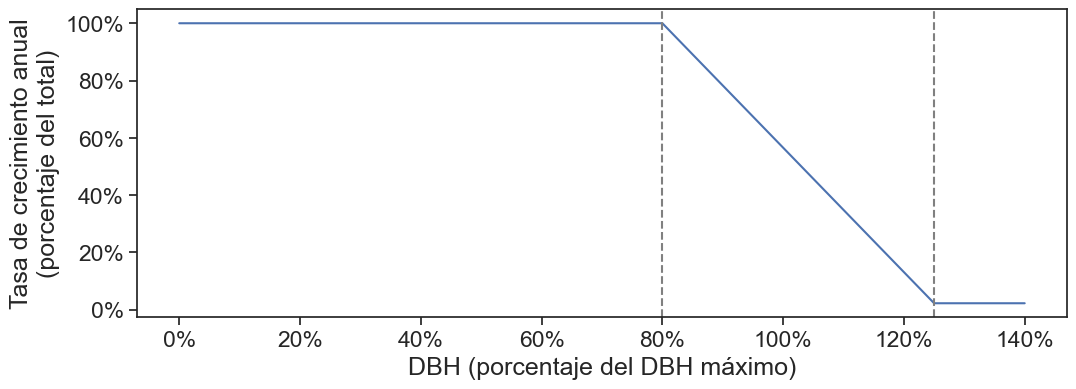

In [6]:
dbh = [0, 0.8, 1.25, 1.4]
rate = [1, 1, 0.022, 0.022]

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dbh, rate)
ax.set_xlabel("DBH (porcentaje del DBH máximo)")
ax.set_ylabel("Tasa de crecimiento anual\n(porcentaje del total)")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.axvline(0.8, c="gray", ls="--")
ax.axvline(1.25, c="gray", ls="--")
fig.savefig(figure_path / "growth_rate_vs_dbh.jpg", dpi=300, bbox_inches="tight")

In [13]:
final_diameters = df_attributes.xs(key=40, level="year")["diameter"].to_numpy()
similar_growth_groups = sorted(
    [np.where(final_diameters == d)[0].tolist() for d in np.unique(final_diameters)],
    key=lambda x: x[0],
)
growth_groups_labels = [
    "\n".join(TREE_NAMES[i] for i in group) for group in similar_growth_groups
]

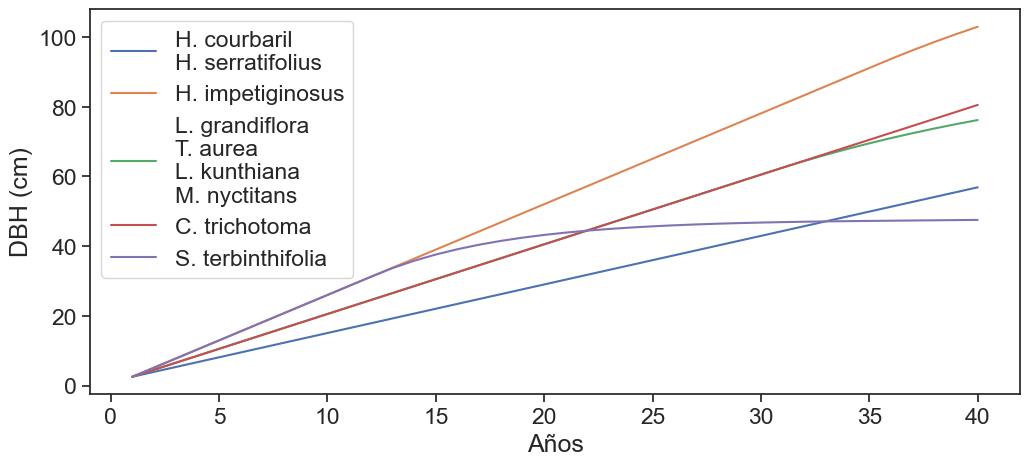

In [18]:
sns.set_theme(style="ticks", font_scale=1.5)

fig, ax = plt.subplots(figsize=(12, 5))
for indices, label in zip(similar_growth_groups, growth_groups_labels, strict=True):
    ax.plot(
        range(1, 41),
        df_attributes.xs(key=indices[0], level="tree")["diameter"],
        label=label,
    )

ax.set_xlabel("Años")
ax.set_ylabel("DBH (cm)")
ax.legend()
fig.savefig(figure_path / "dbh_over_time.jpg", dpi=300, bbox_inches="tight")

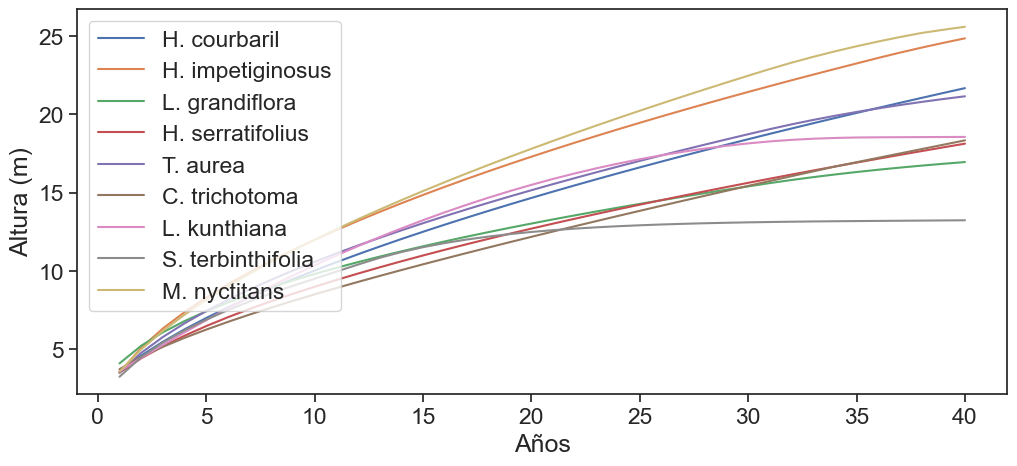

In [19]:
sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(NUM_TREES):
    ax.plot(range(1, 41), df_attributes.xs(key=i, level="tree")["height"], label=TREE_NAMES[i])

ax.set_xlabel("Años")
ax.set_ylabel("Altura (m)")
ax.legend()
fig.savefig(figure_path / "height_over_time.jpg", dpi=300, bbox_inches="tight")

In [ ]:
df_attributes   

name     height   diameter  crown_area        count  \
tree year                                                                
0    1     H. courbaril   3.567627   2.540000    3.842370  2671.000000   
     2     H. courbaril   4.598702   3.933680    5.699974  2590.869499   
     3     H. courbaril   5.483798   5.327359    7.670503  2513.142928   
     4     H. courbaril   6.275640   6.721039    9.746285  2437.748169   
     5     H. courbaril   7.000938   8.114719   11.918575  2364.615266   
...                 ...        ...        ...         ...          ...   
8    36    M. nyctitans  24.657814  71.019811  146.674053   616.397390   
     37    M. nyctitans  24.941371  72.432798  149.805438   597.905352   
     38    M. nyctitans  25.202650  73.763387  152.730076   579.968080   
     39    M. nyctitans  25.407265  75.016383  155.348739   562.568928   
     40    M. nyctitans  25.599947  76.196309  157.811471   545.691755   

           total_crown_area  
tree year                    
0    1         10262.971159  
     2         14767.888211  
     3         19277.069398  
     4         23758.988545  
     5         28182.845273  
...                     ...  
8    36        90409.503675  
     37        89569.473384  
     38        88578.569050  
     39        87394.373417  
     40        86116.418545  

[360 rows x 6 columns]

In [ ]:
sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 5))
all_crown_areas.plot.area(ax=ax)
ax.set_xlim(1, 40)
ax.set_xlabel("Años")
ax.set_ylabel("Área total cubierta (m²)")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
fig.savefig(figure_path / "crown_area_over_time.jpg", dpi=300, bbox_inches="tight")

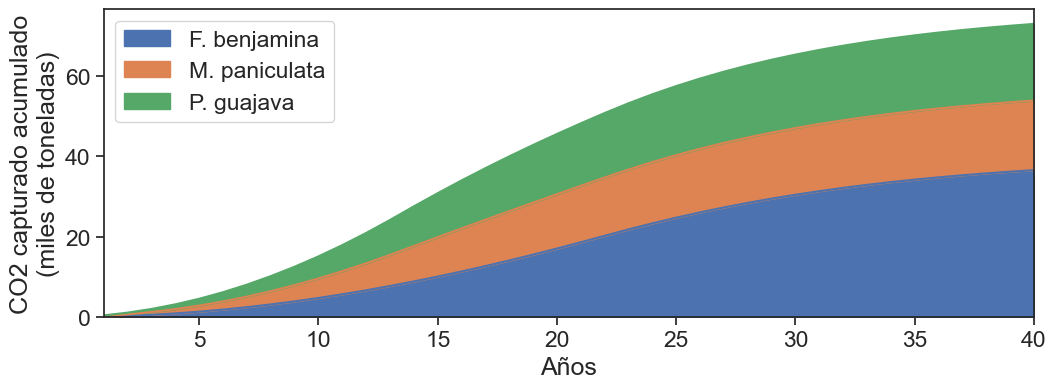

In [146]:
all_sequestrations = []
for i in range(1, 4):
    s = []
    for j in range(40):
        s.append(
            data["data"]["trees"][str(i)]["benefits"]["cumulative"]["category"][j][
                "carbon"
            ]["carbon-dioxide"]["sequestration"],
        )
    all_sequestrations.append(s)

all_sequestrations = pd.DataFrame(
    zip(*all_sequestrations),
    columns=["F. benjamina", "M. paniculata", "P. guajava"],
    index=range(1, 41),
).divide(1e6)

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
all_sequestrations.plot.area(ax=ax)
ax.set_xlim(1, 40)
ax.set_xlabel("Años")
ax.set_ylabel("CO2 capturado acumulado\n(miles de toneladas)")
fig.savefig(
    figure_path / "carbon_sequestration_over_time.jpg",
    dpi=300,
    bbox_inches="tight",
)

In [140]:
all_sequestrations.iloc[-1].sum()

np.float64(72.89341420319307)